In [1]:
import requests
import pandas as pd

headers = {"authorization": f"Apikey"}

def obtener_datos(moneda, simbolo):
    url = "https://min-api.cryptocompare.com/data/v2/histoday"
    params = {"fsym": simbolo, "tsym": "USD", "limit": 2000}  # hasta ~5 años
    response = requests.get(url, headers=headers, params=params)

    if response.status_code != 200:
        print(f" Error con {moneda}: {response.status_code}")
        return pd.DataFrame()

    data = response.json()
    df = pd.DataFrame(data["Data"]["Data"])
    df["time"] = pd.to_datetime(df["time"], unit="s")
    df = df[["time", "open", "high", "low", "close", "volumeto"]]
    df["coin"] = moneda
    return df

monedas = {"bitcoin": "BTC", "ethereum": "ETH", "solana": "SOL"}
dfs = []

for nombre, simbolo in monedas.items():
    print(f"📥 Descargando datos de {nombre}...")
    df_temp = obtener_datos(nombre, simbolo)
    if not df_temp.empty:
        dfs.append(df_temp)

if dfs:
    df_final = pd.concat(dfs)
    df_final.to_csv("criptomonedas_crypto_compare.csv", index=False)
    print("✅ Datos guardados en criptomonedas_crypto_compare.csv")
else:
    print(" No se pudo obtener ningún dato.")




📥 Descargando datos de bitcoin...
📥 Descargando datos de ethereum...
📥 Descargando datos de solana...
✅ Datos guardados en criptomonedas_crypto_compare.csv


In [2]:
import pandas as pd

df = pd.read_csv("criptomonedas_crypto_compare.csv")
df.head()


,time,open,high,low,close,volumeto,coin
0,2020-05-15,9793.19,9841.71,9149.13,9311.69,7.989309e+08,bitcoin
1,2020-05-16,9311.69,9584.90,9224.32,9387.08,3.482624e+08,bitcoin
2,2020-05-17,9387.08,9885.55,9334.23,9670.56,5.058349e+08,bitcoin
3,2020-05-18,9670.56,9943.74,9476.37,9722.73,6.062352e+08,bitcoin
4,2020-05-19,9722.73,9890.69,9471.96,9780.20,5.876600e+08,bitcoin


In [3]:
df = pd.read_csv("criptomonedas_crypto_compare.csv")

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Manejo de valores nulos
df.dropna(inplace=True)

# Verificar tipos de datos
df["time"] = pd.to_datetime(df["time"])

# Ordenar por fecha
df.sort_values(by=["coin", "time"], inplace=True)

# Guardar dataset limpio
df.to_csv("criptomonedas_limpias.csv", index=False)
print("✅ Datos limpios y listos para análisis.")


✅ Datos limpios y listos para análisis.


            open                                                             \
           count          mean           std        min       25%       50%   
coin                                                                          
bitcoin   2001.0  48548.213018  30341.707353  8718.4900  24757.56  41474.72   
ethereum  2001.0   2269.627461   1104.821403   194.7100   1588.56   2193.78   
solana    2001.0     86.288733     74.579763     0.5473     20.82     51.66   

                                 high                ...     close             \
               75%        max   count          mean  ...       75%        max   
coin                                                 ...                        
bitcoin   64119.34  124723.00  2001.0  49546.466002  ...  64156.30  124723.00   
ethereum   3118.76    4830.60  2001.0   2333.030695  ...   3123.72    4830.60   
solana      151.05     261.87  2001.0     89.705960  ...    151.17     261.87   

         volumeto                     

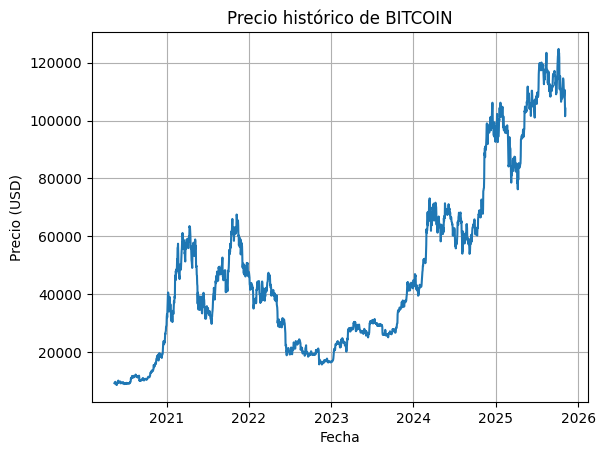

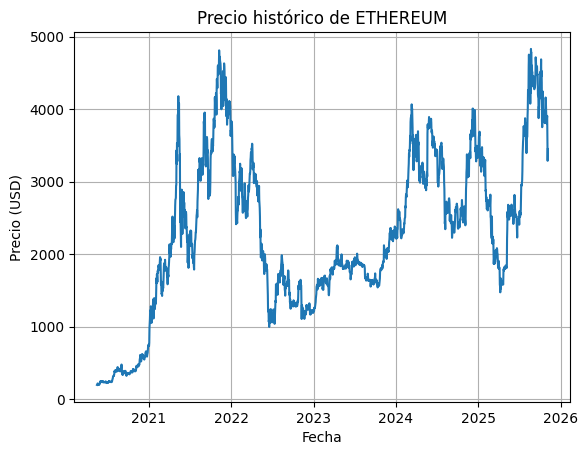

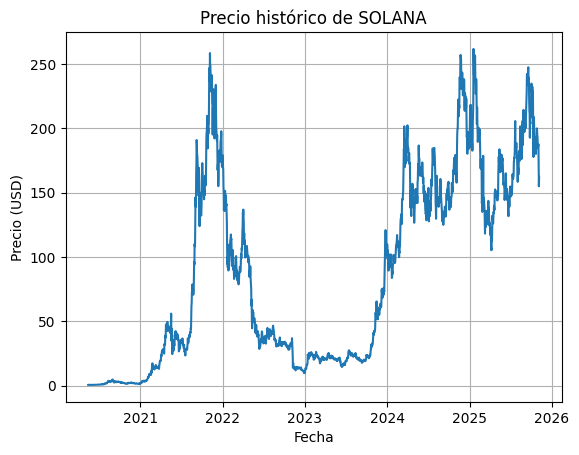

In [4]:
# Estadísticas básicas
estadisticas = df.groupby("coin")[["open", "high", "low", "close", "volumeto"]].describe()
print(estadisticas)

# Promedios por moneda
promedios = df.groupby("coin")[["open", "close", "volumeto"]].mean()
print("\nPromedios generales:\n", promedios)

# Gráficos simples
import matplotlib.pyplot as plt
for coin in df["coin"].unique():
    sub = df[df["coin"] == coin]
    plt.figure()
    plt.plot(sub["time"], sub["close"])
    plt.title(f"Precio histórico de {coin.upper()}")
    plt.xlabel("Fecha")
    plt.ylabel("Precio (USD)")
    plt.grid()
    plt.show()


✅ Datos cargados correctamente.
✅ Datos listos para clusterización (Shape: (6003, 5))

--- K-Means Clustering ---


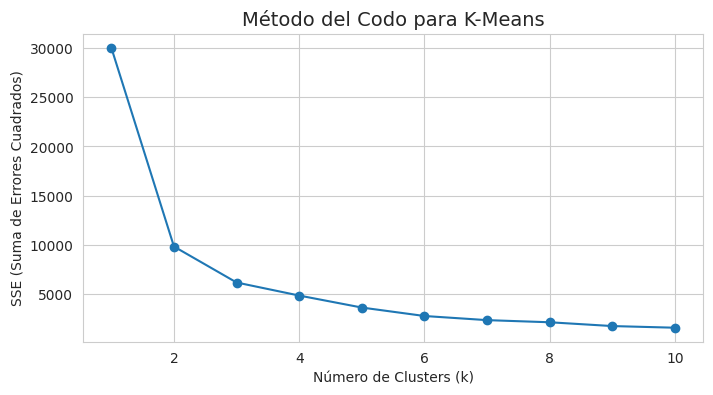

Puntuación de Silueta (K-Means, K=3): 0.6628


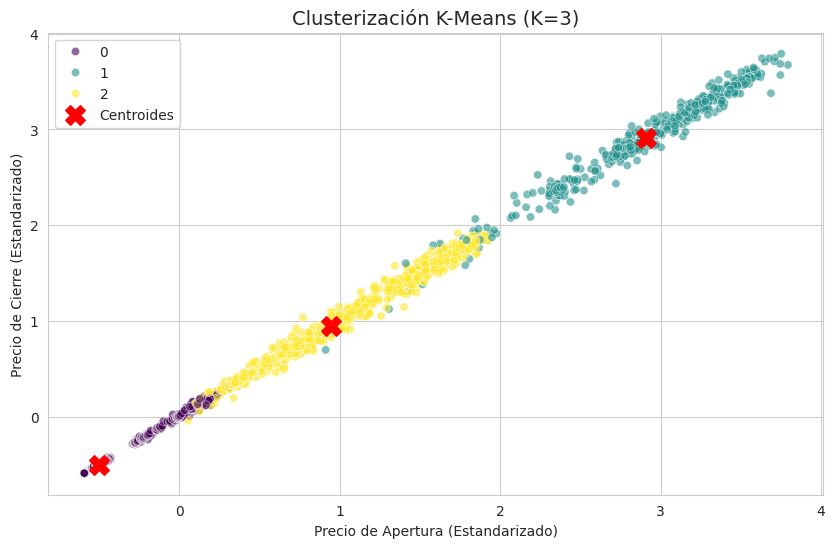


--- DBSCAN Clustering ---
Clusters encontrados (DBSCAN): 1
Puntos de Ruido (-1) (DBSCAN): 39


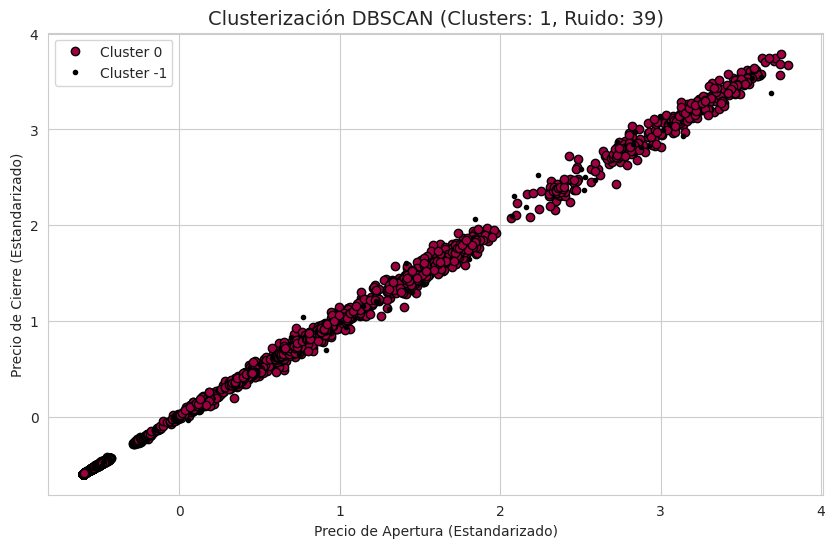


--- Clusterización Jerárquica ---


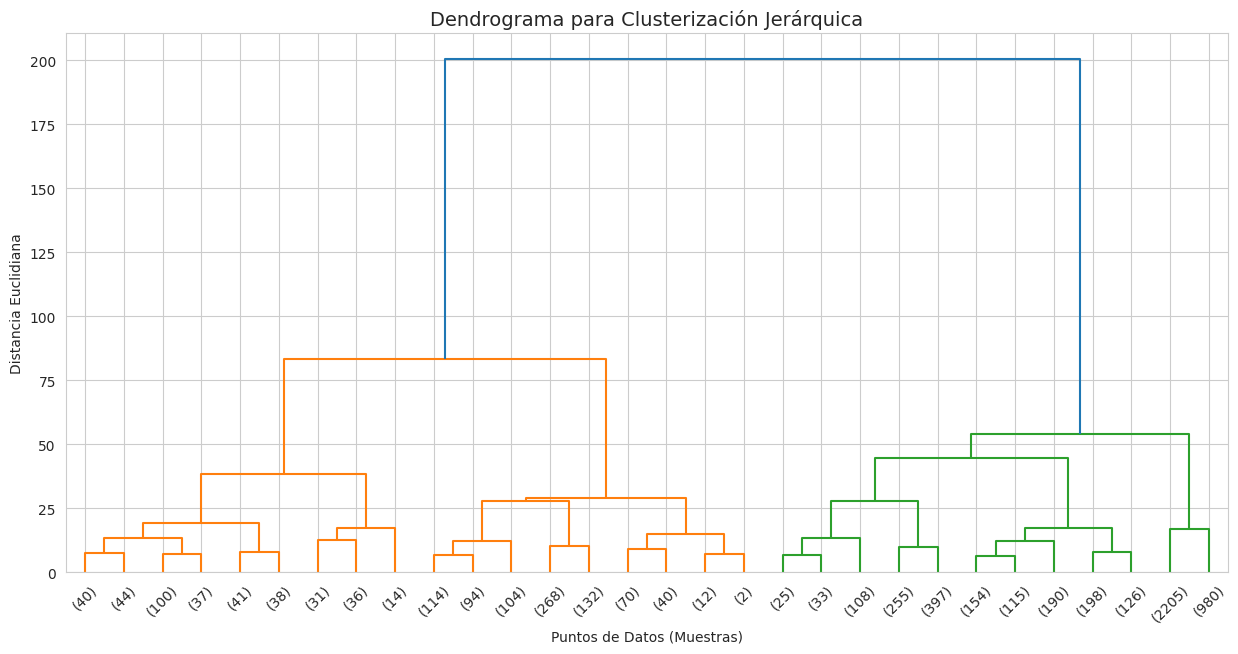

Puntuación de Silueta (Jerárquica, N=3): 0.6703


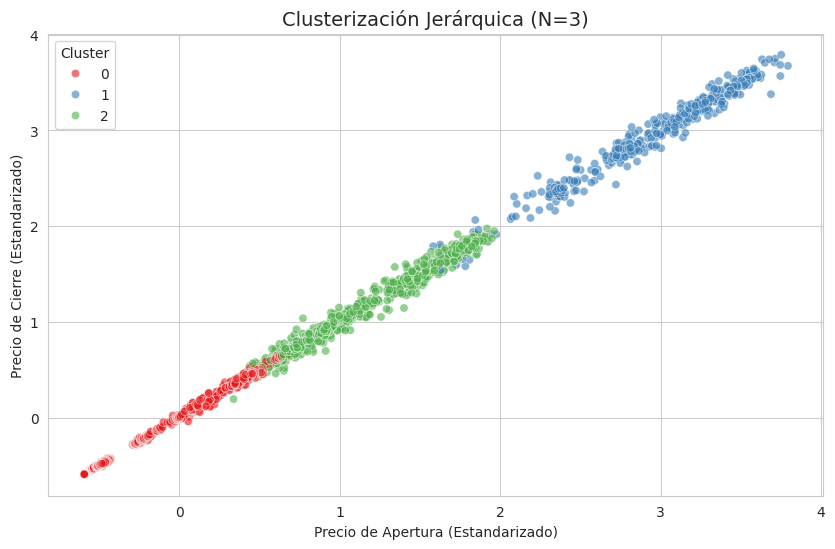


--- Resumen de Clusters K-Means por Moneda ---
       coin  cluster_kmeans  Count
0   bitcoin               0    457
1   bitcoin               1    391
2   bitcoin               2   1153
3  ethereum               0   1999
4  ethereum               2      2
5    solana               0   2001

--- Resumen de Clusters Jerárquicos por Moneda ---
       coin  cluster_agglo  Count
0   bitcoin              0    785
1   bitcoin              1    381
2   bitcoin              2    835
3  ethereum              0   2000
4  ethereum              2      1
5    solana              0   2001


In [ ]:
# SCRIPT DE CLUSTERIZACIÓN PARA DATOS DE CRIPTOMONEDAS

# 1. Instalar librerías adicionales si es necesario (generalmente no se requiere en Colab)
# !pip install scikit-learn matplotlib seaborn

# 2. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import cycle, islice

# Configuración para visualización (opcional)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

# --- Carga y Preparación de Datos ---

# 3. Cargar el archivo CSV
# Asegúrate de que el archivo 'base_datos_criptomonedas.csv'
# se haya subido a tu sesión de Google Colab antes de ejecutar.
file_path = 'criptomonedas_limpias.csv' # Modified file path
try:
    df = pd.read_csv(file_path)
    print(" Datos cargados correctamente.")
except FileNotFoundError:
    print(f" Error: Archivo no encontrado en la ruta: {file_path}")
    # Puedes intentar montar Google Drive si el archivo está allí
    # from google.colab import drive
    # drive.mount('/content/drive')
    # file_path = '/content/drive/MyDrive/ruta/a/base_datos_criptomonedas.csv'
    # df = pd.read_csv(file_path)
    # return # Terminar si no se carga
    exit()

# 4. Preprocesamiento: Seleccionar características y escalar
# Se usarán las columnas numéricas de precios y volumen
features = ['open', 'high', 'low', 'close', 'volumeto']
X = df[features].copy()
coin_names = df['coin'] # Mantener el nombre de la moneda para el análisis

# Estandarización de los datos (fundamental para K-Means y DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(f"✅ Datos listos para clusterización (Shape: {X_scaled.shape})")

# --- 5. TÉCNICA 1: K-MEANS (Clusterización Particionante) ---

print("\n--- K-Means Clustering ---")

# 5.1. Búsqueda del número óptimo de clusters (Método del Codo)
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    sse[k] = kmeans.inertia_ # Suma de errores cuadrados

# 5.2. Visualización del Método del Codo
plt.figure(figsize=(8, 4))
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.title('Método del Codo para K-Means', fontsize=14)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('SSE (Suma de Errores Cuadrados)')
plt.grid(True)
plt.show()

# 5.3. Aplicar K-Means con un número K óptimo (ejemplo: K=3)
# Ajusta K según el gráfico del codo. Aquí se usa un valor por defecto.
K_OPTIMO = 3
kmeans_model = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init='auto')
clusters_kmeans = kmeans_model.fit_predict(X_scaled)
df['cluster_kmeans'] = clusters_kmeans

# 5.4. Evaluar el modelo (Puntuación de Silueta)
score_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print(f"Puntuación de Silueta (K-Means, K={K_OPTIMO}): {score_kmeans:.4f}")

# 5.5. Visualización del Cluster K-Means (usando dos características escaladas)
plt.figure(figsize=(10, 6))
# Usaremos las dos primeras componentes principales si fuera necesario,
# pero por simplicidad se usan 'open' y 'close' estandarizadas.
sns.scatterplot(
    x=X_scaled_df['open'],
    y=X_scaled_df['close'],
    hue=df['cluster_kmeans'],
    palette='viridis',
    legend='full',
    alpha=0.6
)
# Graficar centroides
centers = scaler.inverse_transform(kmeans_model.cluster_centers_)
# Como el scatterplot usa datos escalados, graficamos los centroides escalados
centers_scaled = kmeans_model.cluster_centers_
plt.scatter(
    centers_scaled[:, features.index('open')],
    centers_scaled[:, features.index('close')],
    marker='X',
    s=200,
    color='red',
    label='Centroides'
)
plt.title(f'Clusterización K-Means (K={K_OPTIMO})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend()
plt.show()


# --- 6. TÉCNICA 2: DBSCAN (Clusterización Basada en Densidad) ---

print("\n--- DBSCAN Clustering ---")

# 6.1. Aplicar DBSCAN
# Los parámetros eps y min_samples son clave y dependen del dataset.
# Se usan valores iniciales. Puede requerir ajuste.
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan_model.fit_predict(X_scaled)
df['cluster_dbscan'] = clusters_dbscan
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"Clusters encontrados (DBSCAN): {n_clusters_dbscan}")
print(f"Puntos de Ruido (-1) (DBSCAN): {n_noise}")

# 6.2. Visualización del Cluster DBSCAN
plt.figure(figsize=(10, 6))
# Se usa 'open' y 'close' estandarizadas para la visualización
# Asignar un color a cada cluster, incluido el ruido (-1)
unique_labels = set(clusters_dbscan)
# Handle case where there's only one cluster or noise
if len(unique_labels) == 1 and list(unique_labels)[0] == -1:
    colors = ['k'] # Noise points in black
elif len(unique_labels) == 1:
    colors = ['b'] # Single cluster in blue
else:
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Puntos de ruido en negro
        col_face = 'k'
        marker = '.'
    else:
        col_face = col
        marker = 'o'

    class_member_mask = (clusters_dbscan == k)
    xy = X_scaled[class_member_mask]

    # Handle the case where there's only one cluster or noise
    if len(unique_labels) == 1:
         plt.plot(xy[:, features.index('open')], xy[:, features.index('close')], marker, color=col,
                 markeredgecolor='k', markersize=6, label=f'Cluster {k}')
    else:
         plt.plot(xy[:, features.index('open')], xy[:, features.index('close')], marker, markerfacecolor=col_face,
                 markeredgecolor='k', markersize=6, label=f'Cluster {k}')


plt.title(f'Clusterización DBSCAN (Clusters: {n_clusters_dbscan}, Ruido: {n_noise})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend()
plt.show()


# --- 7. TÉCNICA 3: CLUSTERIZACIÓN JERÁRQUICA (Agglomerative) ---

print("\n--- Clusterización Jerárquica ---")

# 7.1. Generar el enlace (Linkage Matrix) para el dendrograma
# Se utiliza el método 'ward' para minimizar la varianza de los clusters fusionados.
linked = linkage(X_scaled, method='ward')

# 7.2. Visualización del Dendrograma
plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    orientation='top',
    labels=coin_names.to_list(),
    truncate_mode='lastp',  # Muestra solo los últimos 'p' clusters fusionados
    p=30, # Ajusta 'p' para no sobrecargar la gráfica
    show_leaf_counts=True,
    distance_sort='descending'
)
plt.title('Dendrograma para Clusterización Jerárquica', fontsize=14)
plt.xlabel('Puntos de Datos (Muestras)')
plt.ylabel('Distancia Euclidiana')
plt.show()

# 7.3. Aplicar Clusterización Jerárquica con número de clusters fijos (ejemplo: N=3)
# El número de clusters se puede determinar cortando el dendrograma.
N_CLUSTERS_JERARQUICO = 3
agglo_model = AgglomerativeClustering(n_clusters=N_CLUSTERS_JERARQUICO, linkage='ward')
clusters_agglo = agglo_model.fit_predict(X_scaled)
df['cluster_agglo'] = clusters_agglo

# 7.4. Evaluar el modelo (Puntuación de Silueta)
score_agglo = silhouette_score(X_scaled, clusters_agglo)
print(f"Puntuación de Silueta (Jerárquica, N={N_CLUSTERS_JERARQUICO}): {score_agglo:.4f}")

# 7.5. Visualización del Cluster Jerárquico
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled_df['open'],
    y=X_scaled_df['close'],
    hue=df['cluster_agglo'],
    palette='Set1',
    legend='full',
    alpha=0.6
)
plt.title(f'Clusterización Jerárquica (N={N_CLUSTERS_JERARQUICO})', fontsize=14)
plt.xlabel('Precio de Apertura (Estandarizado)')
plt.ylabel('Precio de Cierre (Estandarizado)')
plt.legend(title='Cluster')
plt.show()

# 8. Mostrar resumen de los clusters por moneda (solo para el análisis)
print("\n--- Resumen de Clusters K-Means por Moneda ---")
cluster_summary = df.groupby(['coin', 'cluster_kmeans']).size().reset_index(name='Count')
print(cluster_summary)

print("\n--- Resumen de Clusters Jerárquicos por Moneda ---")
cluster_summary_agglo = df.groupby(['coin', 'cluster_agglo']).size().reset_index(name='Count')
print(cluster_summary_agglo)

Columnas disponibles: ['time', 'open', 'high', 'low', 'close', 'volumeto', 'coin']
         time     open     high      low    close      volumeto     coin
0  2020-05-15  9793.19  9841.71  9149.13  9311.69  7.989309e+08  bitcoin
1  2020-05-16  9311.69  9584.90  9224.32  9387.08  3.482624e+08  bitcoin
2  2020-05-17  9387.08  9885.55  9334.23  9670.56  5.058349e+08  bitcoin
3  2020-05-18  9670.56  9943.74  9476.37  9722.73  6.062352e+08  bitcoin
4  2020-05-19  9722.73  9890.69  9471.96  9780.20  5.876600e+08  bitcoin
No se encontró columna de fecha. Se usará índice entero en lugar de fechas.
Features usadas para clustering: ['open', 'high', 'low', 'close', 'volumeto']
Número de muestras para clustering: 6003
Usando KMeans con n_clusters = 3
Silhouette KMeans: 0.6658277625374425
Etiquetas DBSCAN (muestra): [-1  0]
AgglomerativeClustering con n_clusters = 3
Ejemplo de coin seleccionada para series temporales: bitcoin


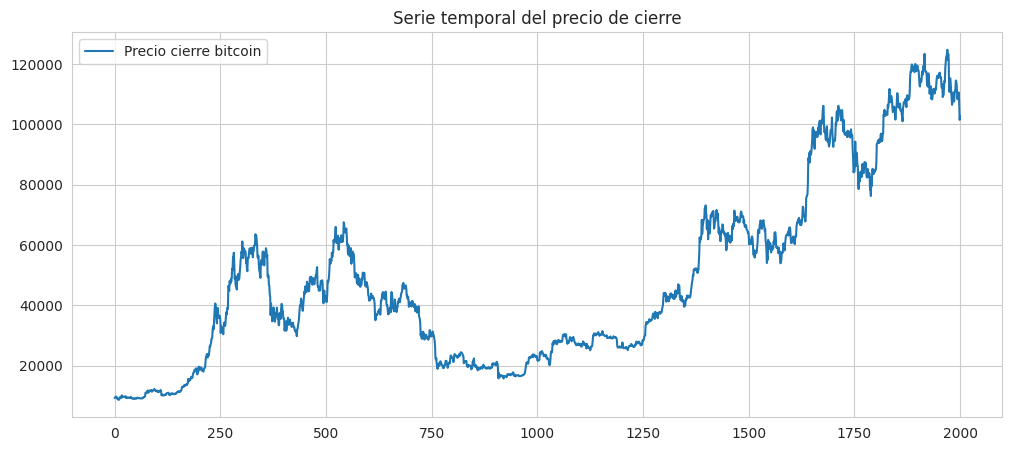

RMSE ARIMA: 38362.0032


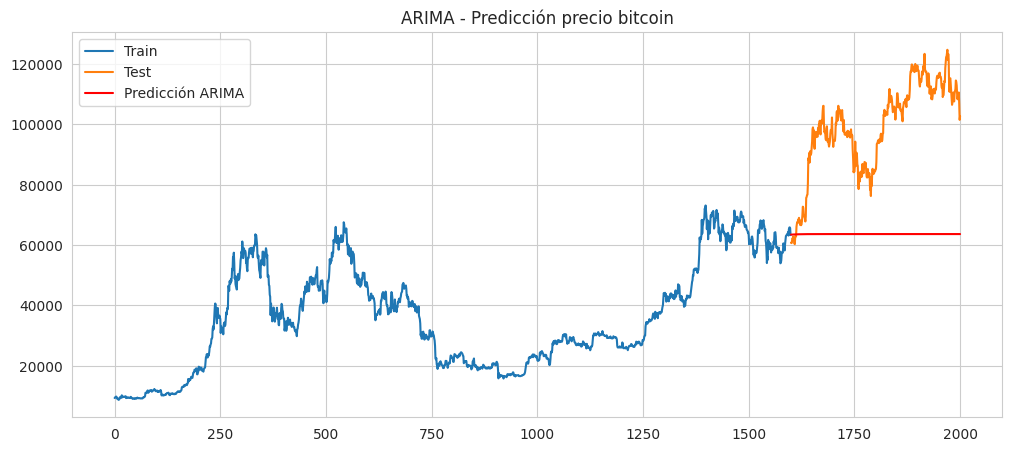

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0704
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0077
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0066
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0057
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0068
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0052
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0043
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0048
Epoch 9/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047
Epoch 10/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0043
Epoch 11/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0033
Epoch 12/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039
Epoch 13/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0038
Epoch 14/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0032
Epoch 15/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031


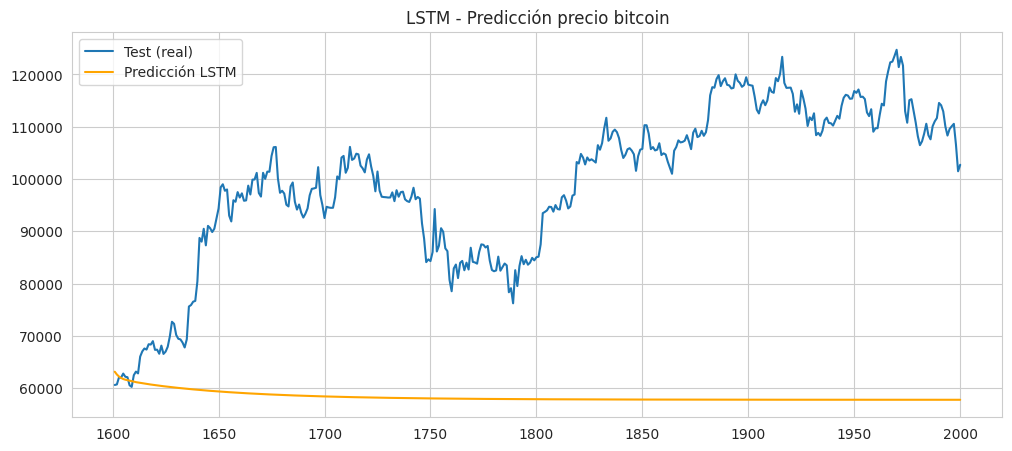

In [ ]:
# ===============================================================
# PROYECTO DE CLUSTERIZACIÓN Y PREDICCIÓN DE SERIES TEMPORALES
# Versión corregida y robusta
# ===============================================================

# 1️⃣ Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

sns.set_style("whitegrid")

# ===============================================================
# 2️⃣ CARGA Y PREPROCESAMIENTO (robusto frente a nombres de columna)
# ===============================================================
df = pd.read_csv('criptomonedas_limpias.csv')  # ajusta path si hace falta
print("Columnas disponibles:", df.columns.tolist())
print(df.head())

# Normalizar nombre columna fecha: buscar variantes comunes
date_candidates = ['date', 'Date', 'fecha', 'Fecha', 'timestamp', 'Timestamp']
date_col = next((c for c in date_candidates if c in df.columns), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    # Si la columna se llama distinto, renombramos internamente a 'date'
    if date_col != 'date':
        df.rename(columns={date_col: 'date'}, inplace=True)
    print(f"Usando columna de fecha: 'date' (antes '{date_col}')")
else:
    print("No se encontró columna de fecha. Se usará índice entero en lugar de fechas.")
    # opción: crear una columna date incremental (opcional)
    df['date'] = pd.RangeIndex(start=0, stop=len(df), step=1)

# Asegurar columna 'coin'
if 'coin' not in df.columns:
    # si no existe, intentar detectar una columna parecida
    coin_candidates = ['symbol', 'Symbol', 'ticker', 'Ticker']
    coin_col = next((c for c in coin_candidates if c in df.columns), None)
    if coin_col:
        df.rename(columns={coin_col: 'coin'}, inplace=True)
        print(f"Renombrada columna '{coin_col}' a 'coin'.")
    else:
        # si no hay coin, crear una coin ficticia para todo (evita errores)
        df['coin'] = 'coin_unknown'
        print("No se encontró columna 'coin'. Se creó 'coin' con valor 'coin_unknown' para todo el DF.")

# Ordenar por coin y date si la fecha es válida
if df['date'].notna().any():
    df = df.sort_values(by=['coin', 'date']).reset_index(drop=True)

# Seleccionar variables numéricas para clustering (solo las que existan)
requested_features = ['open', 'high', 'low', 'close', 'volumeto']
features = [f for f in requested_features if f in df.columns]
if not features:
    raise ValueError(f"Ninguna de las columnas esperadas para features existe en el CSV. Buscadas: {requested_features}")
print("Features usadas para clustering:", features)

# Quitar filas con NaNs en features
df = df.dropna(subset=features).reset_index(drop=True)
if df.empty:
    raise ValueError("DataFrame vacío después de eliminar NaNs en las features de clustering.")

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================================================
# 3️⃣ CLUSTERIZACIÓN (con comprobaciones)
# ===============================================================
n_samples = X_scaled.shape[0]
print("Número de muestras para clustering:", n_samples)

# --- KMeans ---
# Asegurar número de clusters válido
desired_k = 3
k = min(desired_k, max(2, n_samples - 1))  # K debe ser >=2 y <= n_samples-1
print(f"Usando KMeans con n_clusters = {k}")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Silhouette solo si hay al menos 2 clusters únicos
unique_labels = np.unique(df['cluster_kmeans'])
if len(unique_labels) > 1 and n_samples >= 2:
    try:
        sil = silhouette_score(X_scaled, df['cluster_kmeans'])
        print("Silhouette KMeans:", sil)
    except Exception as e:
        print("No se pudo calcular silhouette score:", e)
else:
    print("No hay suficientes clusters distintos para calcular silhouette score (KMeans).")

# --- DBSCAN ---
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
print("Etiquetas DBSCAN (muestra):", np.unique(df['cluster_dbscan'])[:10])

# --- Jerárquico ---
agg_k = min(3, max(2, n_samples - 1))
print(f"AgglomerativeClustering con n_clusters = {agg_k}")
agglo = AgglomerativeClustering(n_clusters=agg_k, linkage='ward')
df['cluster_agglo'] = agglo.fit_predict(X_scaled)

# ===============================================================
# 4️⃣ ANÁLISIS DE SERIES TEMPORALES (elegir coin y robustecer)
# ===============================================================
coin_example = df['coin'].unique()[0]
print("Ejemplo de coin seleccionada para series temporales:", coin_example)

df_coin = df[df['coin'] == coin_example].copy()
# Si 'date' es convertible a datetime y tiene valores distintos, lo usamos como índice
if pd.api.types.is_datetime64_any_dtype(df_coin['date']):
    df_coin = df_coin.set_index('date').sort_index()
    serie = df_coin['close']
else:
    # si no hay fechas reales, crear índice entero
    df_coin = df_coin.reset_index(drop=True)
    serie = df_coin['close']
    # asignar índice como fecha falsa para gráficas si quieres:
    df_coin.index.name = 'index'

if serie.dropna().empty:
    raise ValueError(f"La serie 'close' para la moneda {coin_example} está vacía o es todo NaN.")

plt.figure(figsize=(12, 5))
plt.plot(serie, label=f"Precio cierre {coin_example}")
plt.title("Serie temporal del precio de cierre")
plt.legend()
plt.show()

# ===============================================================
# 5️⃣ MODELO ARIMA (con comprobaciones de tamaño de serie)
# ===============================================================
min_points_for_arima = 10  # umbral simple
if len(serie) < min_points_for_arima:
    print(f"Serie demasiado corta para ARIMA (n={len(serie)}). Se omite ARIMA.")
else:
    train_size = int(len(serie) * 0.8)
    train, test = serie.iloc[:train_size], serie.iloc[train_size:]
    if len(test) == 0:
        print("No hay datos de test (serie corta). Se ajusta train/test automáticamente.")
        train, test = serie.iloc[:-1], serie.iloc[-1:]
    try:
        model = ARIMA(train, order=(2, 1, 2))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(test))
        rmse = sqrt(mean_squared_error(test, forecast))
        print(f"RMSE ARIMA: {rmse:.4f}")

        plt.figure(figsize=(12, 5))
        plt.plot(train, label='Train')
        plt.plot(test, label='Test')
        plt.plot(test.index, forecast, label='Predicción ARIMA', color='red')
        plt.legend()
        plt.title(f"ARIMA - Predicción precio {coin_example}")
        plt.show()
    except Exception as e:
        print("Error entrenando/prediciendo ARIMA:", e)

# ===============================================================
# 6️⃣ MODELO LSTM (RNN) - implementación robusta y shapes correctas
# ===============================================================
# Necesitamos usar la misma serie completa (ordenada) y separar train/test de manera coherente
serie_values = serie.dropna().values.reshape(-1, 1)
if len(serie_values) < 20:
    print(f"Serie demasiado corta para LSTM (n={len(serie_values)}). Se omite LSTM.")
else:
    # normalizar para LSTM
    scaler_lstm = StandardScaler()
    data_scaled = scaler_lstm.fit_transform(serie_values)

    # Definir tamaños
    n_input = 10
    test_size = max(1, int(len(data_scaled) * 0.2))
    train_size = len(data_scaled) - test_size

    train_scaled = data_scaled[:train_size]
    test_scaled = data_scaled[train_size:]

    # Generador de secuencias (solo para train)
    generator = TimeseriesGenerator(train_scaled, train_scaled, length=n_input, batch_size=16)

    if len(generator) == 0:
        print("No hay suficientes secuencias para crear TimeseriesGenerator (reduce n_input o usa más datos).")
    else:
        tf.keras.backend.clear_session()
        model_lstm = Sequential([
            LSTM(50, activation='tanh', input_shape=(n_input, 1)),
            Dense(1)
        ])
        model_lstm.compile(optimizer='adam', loss='mse')

        # Entrenar
        model_lstm.fit(generator, epochs=20, verbose=1)

        # Predicción paso-a-paso sobre el período de test
        # Empezamos con la última ventana del conjunto de train
        last_window = train_scaled[-n_input:].reshape(1, n_input, 1)
        preds_scaled = []
        curr_batch = last_window.copy()

        for i in range(len(test_scaled)):
            pred_scaled = model_lstm.predict(curr_batch, verbose=0)[0]
            preds_scaled.append(pred_scaled)
            # desplazar ventana y añadir predicción
            curr_batch = np.append(curr_batch[:, 1:, :], [[pred_scaled]], axis=1)

        preds_scaled = np.array(preds_scaled).reshape(-1, 1)
        # Invertir escala
        try:
            pred_rescaled = scaler_lstm.inverse_transform(preds_scaled)
        except Exception as e:
            print("Error en inverse_transform de LSTM:", e)
            pred_rescaled = preds_scaled  # fallback

        # Preparar índices para graficar (usar índices reales del test)
        if isinstance(serie.index, pd.DatetimeIndex):
            test_index = serie.index[train_size:]
        else:
            test_index = serie.index[train_size:]

        plt.figure(figsize=(12, 5))
        plt.plot(test_index, serie_values[train_size:].flatten(), label='Test (real)')
        plt.plot(test_index, pred_rescaled.flatten(), label='Predicción LSTM', color='orange')
        plt.legend()
        plt.title(f"LSTM - Predicción precio {coin_example}")
        plt.show()



Silhouette KMeans: 0.6627374486321146


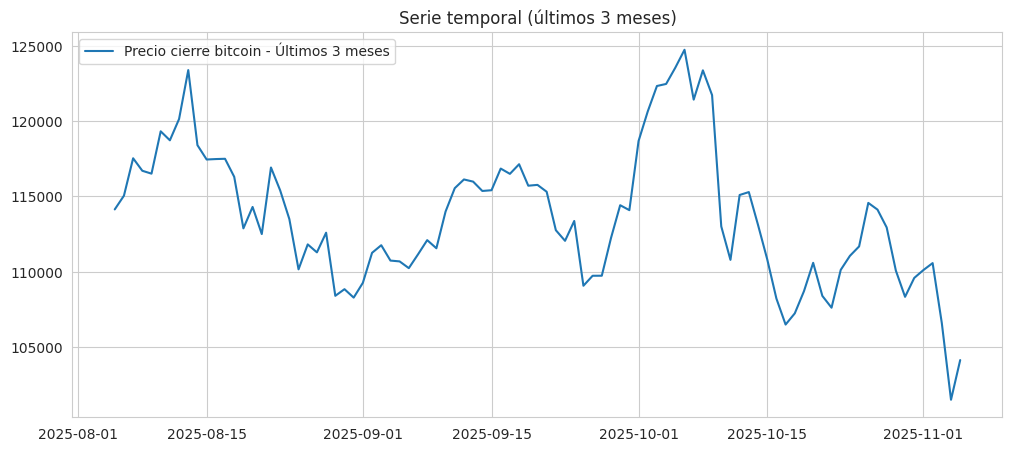

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

RMSE ARIMA (últimos 3 meses): 4350.0547


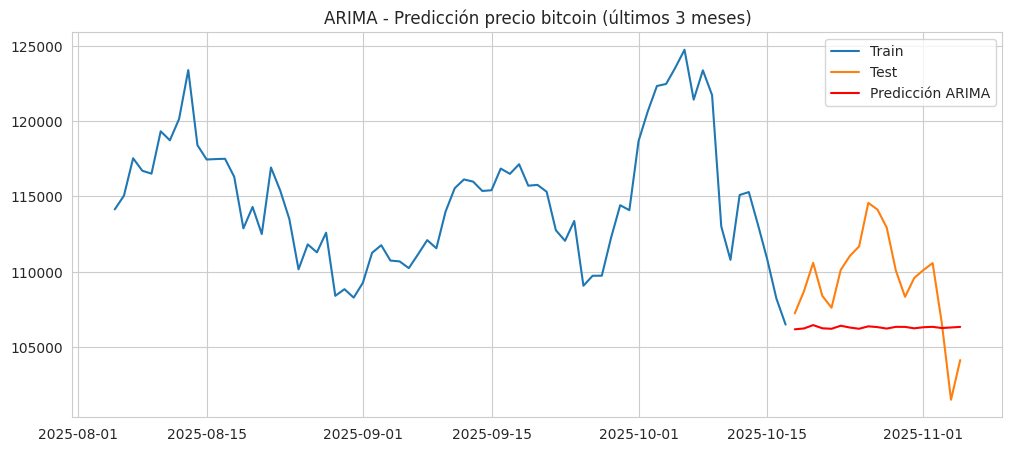

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9146
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0221 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7125 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6500 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1348 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8809 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6752 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.9938 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4644 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6421
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3742 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3385 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7059 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4302 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3536 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

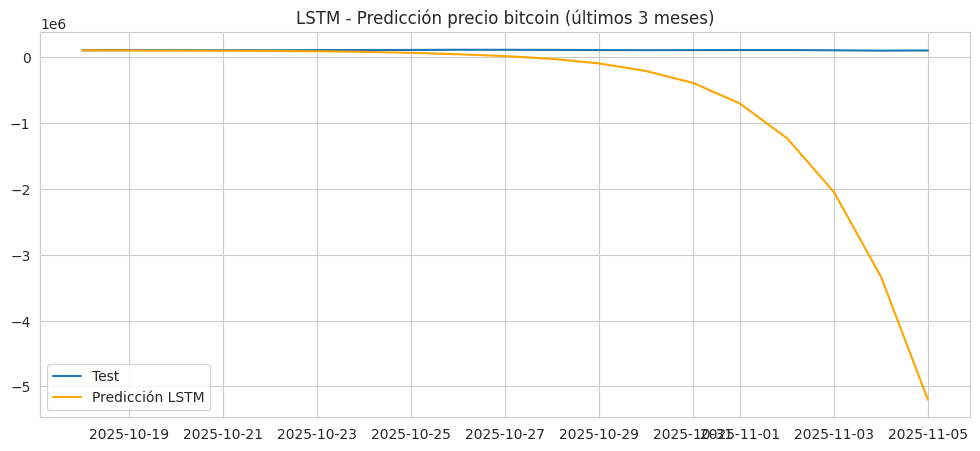

In [7]:
# ===============================================================
# PROYECTO DE CLUSTERIZACIÓN Y PREDICCIÓN DE SERIES TEMPORALES
# Adaptado a columna 'time' y últimos 3 meses
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

sns.set_style("whitegrid")

# ===============================================================
# 1️⃣ CARGA Y PREPROCESAMIENTO
# ===============================================================
df = pd.read_csv('criptomonedas_limpias.csv')

# Convertir la columna 'time' a datetime
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by=['coin', 'time']).reset_index(drop=True)

# ===============================================================
# 2️⃣ CLUSTERIZACIÓN
# ===============================================================
features = ['open', 'high', 'low', 'close', 'volumeto']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)
print("Silhouette KMeans:", silhouette_score(X_scaled, df['cluster_kmeans']))

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Agglomerative
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_agglo'] = agglo.fit_predict(X_scaled)

# ===============================================================
# 3️⃣ SERIES TEMPORALES (ÚLTIMOS 3 MESES)
# ===============================================================
coin_example = df['coin'].unique()[0]
df_coin = df[df['coin'] == coin_example].set_index('time')

# Filtrar últimos 3 meses
fecha_max = df_coin.index.max()
fecha_min = fecha_max - pd.DateOffset(months=3)
df_3m = df_coin.loc[fecha_min:fecha_max]

serie = df_3m['close']

plt.figure(figsize=(12, 5))
plt.plot(serie, label=f"Precio cierre {coin_example} - Últimos 3 meses")
plt.title("Serie temporal (últimos 3 meses)")
plt.legend()
plt.show()

# ===============================================================
# 4️⃣ MODELO ARIMA
# ===============================================================
train_size = int(len(serie) * 0.8)
train, test = serie.iloc[:train_size], serie.iloc[train_size:]

model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))
rmse = sqrt(mean_squared_error(test, forecast))
print(f"RMSE ARIMA (últimos 3 meses): {rmse:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='Predicción ARIMA', color='red')
plt.legend()
plt.title(f"ARIMA - Predicción precio {coin_example} (últimos 3 meses)")
plt.show()

# ===============================================================
# 5️⃣ MODELO LSTM (RNN)
# ===============================================================
data_lstm = serie.values.reshape(-1, 1)
scaler_lstm = StandardScaler()
data_scaled = scaler_lstm.fit_transform(data_lstm)

n_input = 10
generator = TimeseriesGenerator(data_scaled, data_scaled, length=n_input, batch_size=16)

model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(n_input, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(generator, epochs=20, verbose=1)

# Predicción LSTM
predictions = []
batch = data_scaled[-n_input:].reshape((1, n_input, 1))
for i in range(len(test)):
    pred = model_lstm.predict(batch, verbose=0)[0]
    predictions.append(pred)
    batch = np.append(batch[:, 1:, :], [[pred]], axis=1)

pred_rescaled = scaler_lstm.inverse_transform(predictions)

plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Test')
plt.plot(test.index, pred_rescaled, label='Predicción LSTM', color='orange')
plt.legend()
plt.title(f"LSTM - Predicción precio {coin_example} (últimos 3 meses)")
plt.show()
